<a href="https://colab.research.google.com/github/HussainHaider/agentic-AI-cohort/blob/main/sesssion4/crewai_usecase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install crewai 'crewai[tools]' langchain-openai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.4/68.4 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 976.4/976.4 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 111.5/111.5 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 809.6/809.6 kB 38.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.9/19.9 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
import getpass

os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OPENAI_API_KEY: ")
os.environ["SERPER_API_KEY"] = getpass.getpass("Enter your SERPER_API_KEY from serper.dev: ")

# Optional: choose model
os.environ["OPENAI_MODEL_NAME"] = "gpt-5-nano"

Enter your OPENAI_API_KEY: ··········
Enter your SERPER_API_KEY from serper.dev: ··········


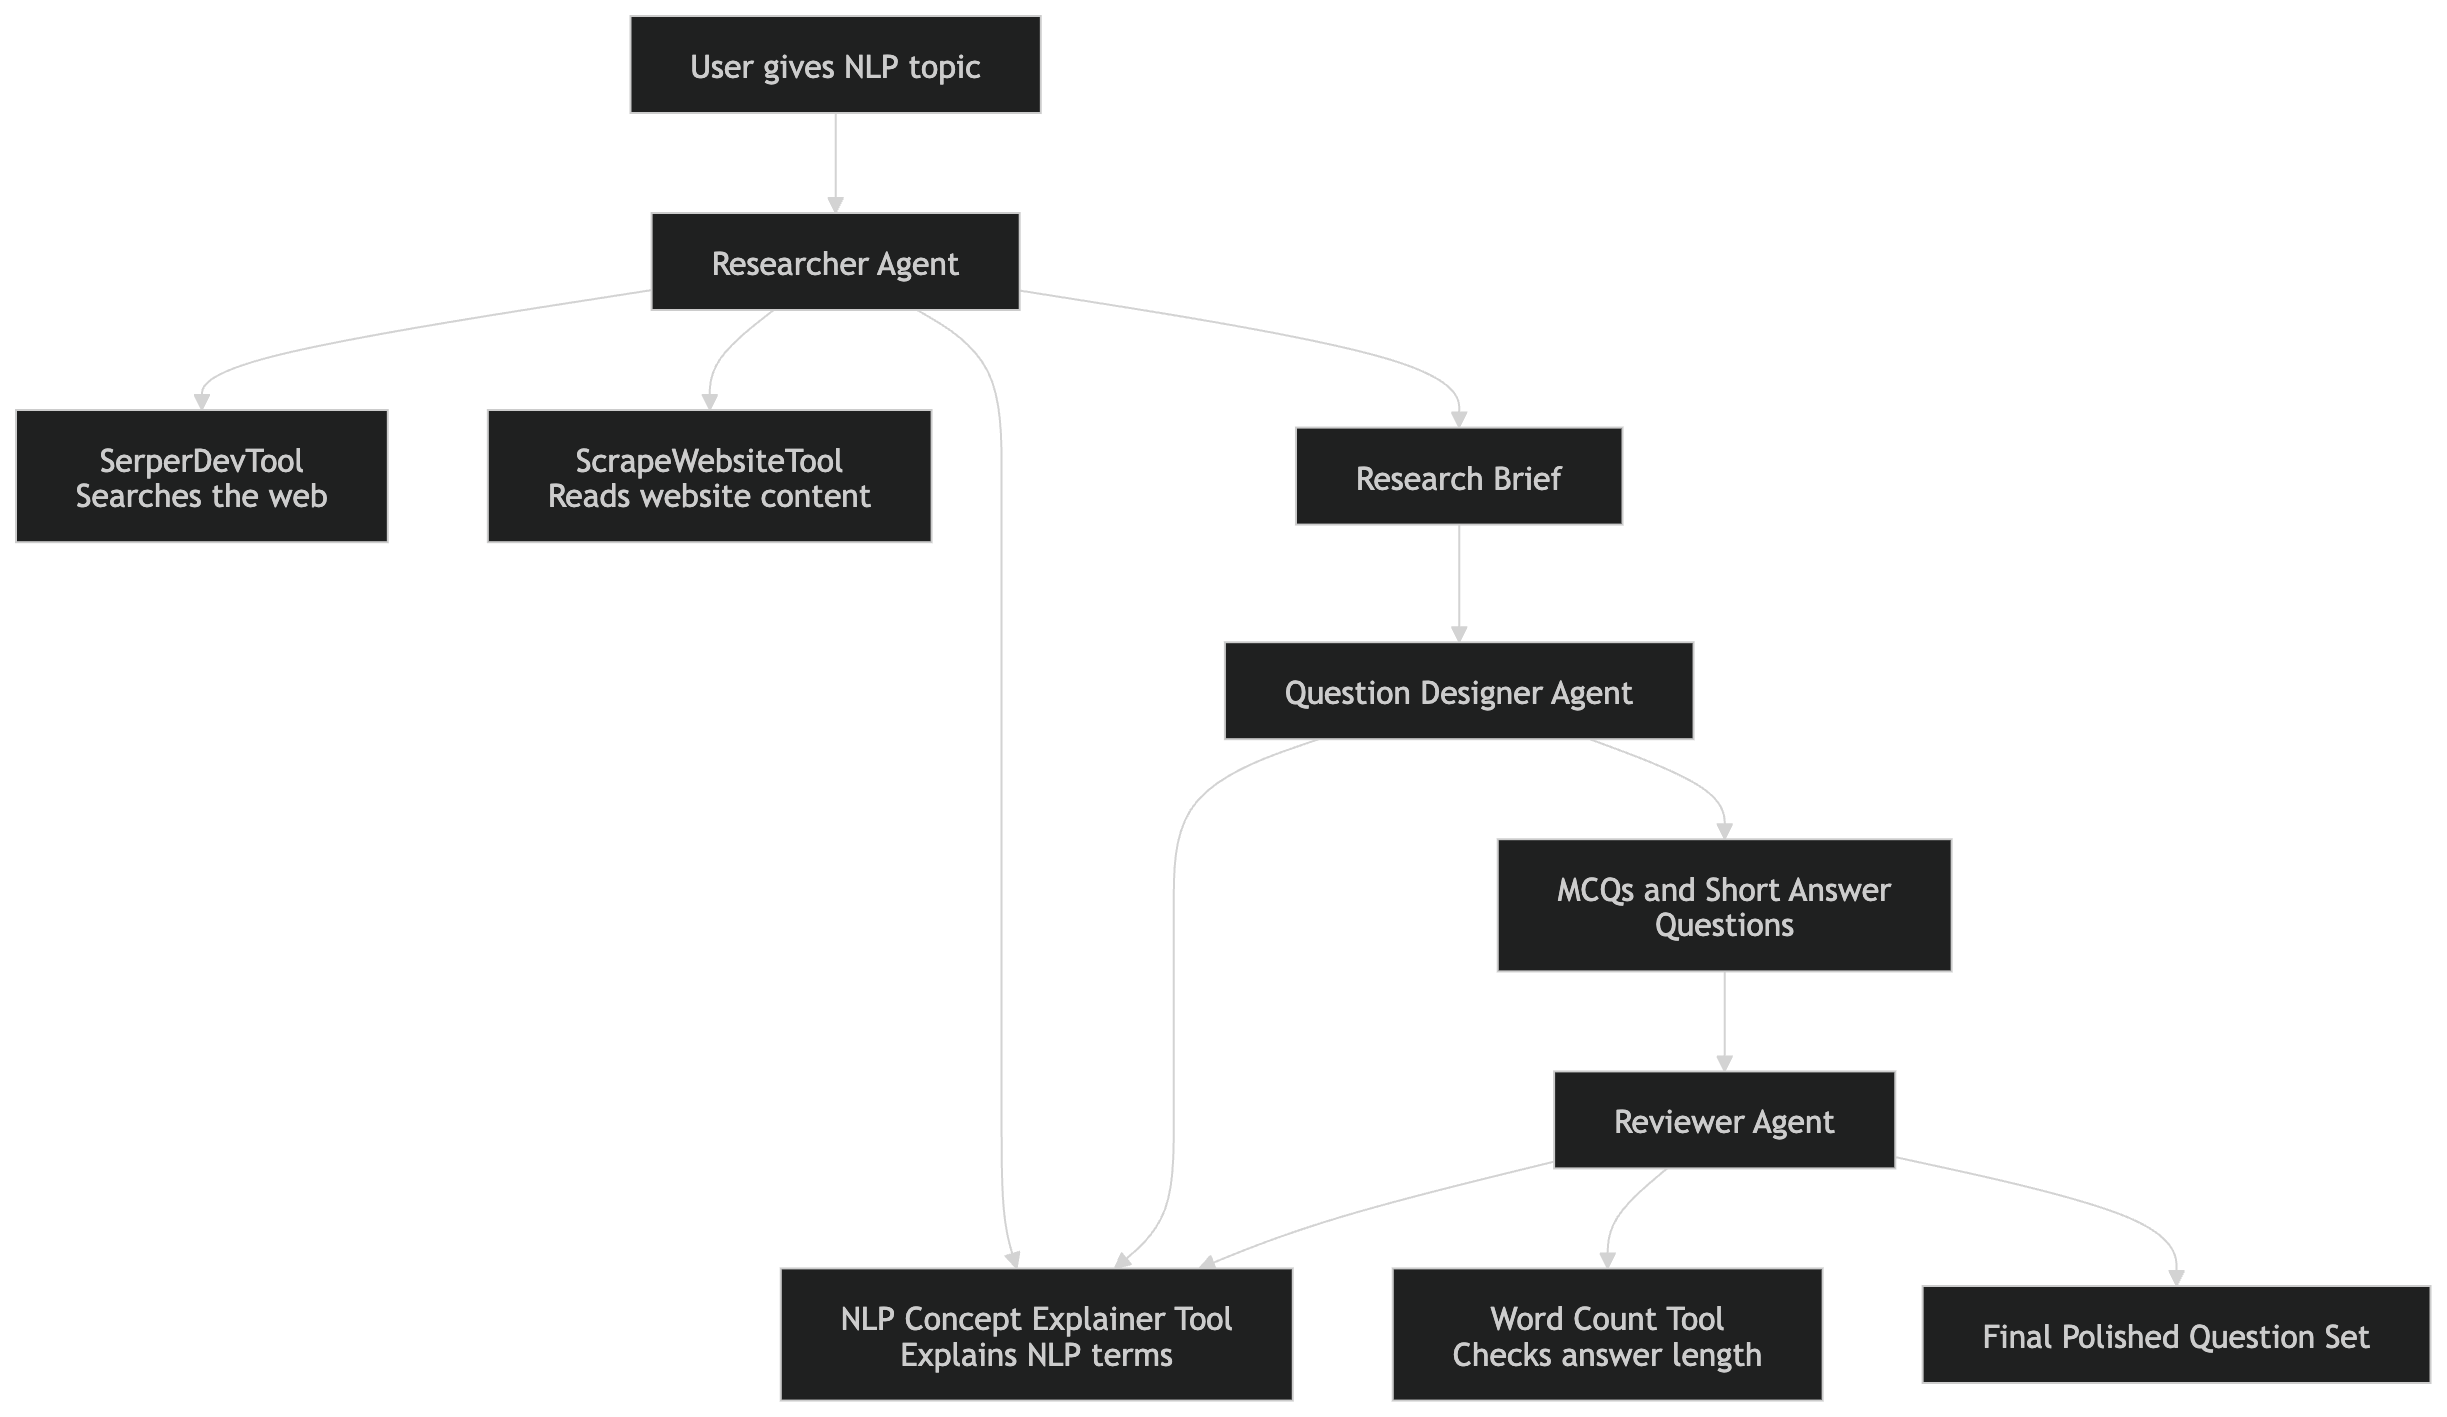

In [ ]:
# Create multiple tools
# ============================================================

from crewai_tools import SerperDevTool, ScrapeWebsiteTool
from crewai.tools import tool

# Built-in CrewAI tools
search_tool = SerperDevTool()
scrape_tool = ScrapeWebsiteTool()


@tool("Word Count Tool")
def word_count_tool(text: str) -> str:
    """
    Counts the number of words in a text.
    Useful for checking whether generated content is concise.
    """
    words = text.split()
    return f"The text contains {len(words)} words."


@tool("NLP Concept Explainer Tool")
def nlp_concept_explainer_tool(concept: str) -> str:
    """
    Gives a simple explanation of a common NLP concept.
    Useful when agents need quick background context.
    """
    explanations = {
        "tokenization": "Tokenization splits text into smaller units such as words, subwords, or characters.",
        "stemming": "Stemming reduces words to their base or root form, often using simple rules.",
        "lemmatization": "Lemmatization reduces words to their dictionary form using vocabulary and grammar.",
        "sentiment analysis": "Sentiment analysis identifies whether text expresses positive, negative, or neutral emotion.",
        "named entity recognition": "Named Entity Recognition identifies entities such as people, places, organizations, and dates.",
        "embeddings": "Embeddings convert text into numerical vectors that capture semantic meaning.",
    }

    key = concept.lower().strip()
    return explanations.get(
        key,
        f"{concept} is an NLP concept. Explain it clearly with definition, use case, and example."
    )

In [ ]:
# Create multiple agents
# ============================================================

from crewai import Agent, Task, Crew, Process

researcher = Agent(
    role="Senior NLP Researcher",

    goal=("Research the latest and most useful information about NLP topics, "
        "including definitions, applications, and examples."),
    backstory=(
        "You are a senior NLP researcher with deep experience in language models, "
        "text processing, information retrieval, and AI education. You are excellent "
        "at finding accurate information and summarizing it for students."
    ),
    tools=[search_tool, scrape_tool, nlp_concept_explainer_tool],
    allow_delegation=False,
    verbose=True,
)

question_designer = Agent(
    role="Assessment Question Designer",
    goal=(
        "Create high-quality MCQs and short-answer questions for university students "
        "studying Natural Language Processing."
    ),
    backstory=(
        "You are a university lecturer who designs exams and quizzes. You specialize "
        "in creating clear, fair, and conceptually strong questions with accurate answers."
    ),
    tools=[nlp_concept_explainer_tool],
    allow_delegation=False,
    verbose=True,
)

reviewer = Agent(
    role="Academic Quality Reviewer",
    goal=(
        "Review generated questions for clarity, correctness, difficulty balance, "
        "and formatting quality."
    ),
    backstory=(
        "You are an experienced academic reviewer. You check whether questions are "
        "accurate, understandable, well-structured, and useful for student assessment."
    ),
    tools=[word_count_tool, nlp_concept_explainer_tool],
    allow_delegation=False,
    verbose=True,
)

In [ ]:
# Create tasks
# ============================================================

research_task = Task(
    description=(
        "Research the topic: {topic}. "
        "Focus on core concepts, real-world applications, important terminology, "
        "and common student misconceptions. "
        "Use the available tools when helpful."
    ),
    expected_output=(
        "A concise research brief about {topic}, including:\n"
        "- 5 key concepts\n"
        "- 3 practical applications\n"
        "- 3 common misconceptions\n"
        "- Short examples that can help create exam questions"
    ),
    agent=researcher,
)

question_generation_task = Task(
    description=(
        "Using the research brief, create assessment questions about {topic}. "
        "Generate exactly 5 MCQs and exactly 5 short-answer questions. "
        "Each MCQ must have 4 options labeled A, B, C, and D. "
        "Each MCQ must include the correct answer and a one-sentence explanation."
    ),
    expected_output=(
        "A well-formatted question set with:\n\n"
        "Section 1: MCQs\n"
        "- Exactly 5 MCQs\n"
        "- 4 options for each MCQ\n"
        "- Correct answer clearly marked\n"
        "- One-sentence explanation for each answer\n\n"
        "Section 2: Short-Answer Questions\n"
        "- Exactly 5 short-answer questions\n"
        "- Model answer for each question"
    ),
    agent=question_designer,
    context=[research_task],
)

review_task = Task(
    description=(
        "Review the generated question set. Improve clarity, remove ambiguity, "
        "verify that answers are correct, and ensure the format is clean. "
        "Keep exactly 5 MCQs and exactly 5 short-answer questions."
    ),
    expected_output=(
        "The final polished question set about {topic}. "
        "Your final answer MUST include:\n"
        "1. 5 MCQs with A-D options, correct answer, and explanation\n"
        "2. 5 short-answer questions with model answers\n"
        "3. A short quality checklist confirming correctness, clarity, and format"
    ),
    agent=reviewer,
    context=[question_generation_task],
)

In [ ]:
# Create and run the crew
# ============================================================

crew = Crew(
    agents=[researcher, question_designer, reviewer],
    tasks=[research_task, question_generation_task, review_task],
    process=Process.sequential,
    verbose=True,
)

# Colab/Jupyter friendly:
result = await crew.kickoff_async(
    inputs={
        "topic": "Natural Language Processing fundamentals"
    }
)

print(result)

╭─────────────────────────────────────────── 🚀 Crew Execution Started ───────────────────────────────────────────╮
│                                                                                                                 │
│  Crew Execution Started                                                                                         │
│  Name: crew                                                                                                     │
│  ID: fc1543be-a3cf-43b5-a3ac-5a2fb9364a3e                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 📋 Task Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Started                                                                                                   │
│  Name: Research the topic: Natural Language Processing fundamentals. Focus on core concepts, real-world         │
│  applications, important terminology, and common student misconceptions. Use the available tools when helpful.  │
│  ID: e066537b-392e-4a8c-aec1-c961af9f48a4                                                                       │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior NLP Researcher                                                                                   │
│                                                                                                                 │
│  Task: Research the topic: Natural Language Processing fundamentals. Focus on core concepts, real-world         │
│  applications, important terminology, and common student misconceptions. Use the available tools when helpful.  │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[Finalize] todos_count=0, todos_with_results=0


╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Senior NLP Researcher                                                                                   │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  Natural Language Processing fundamentals — concise research brief                                              │
│                                                                                                                 │
│  1) 5 key concepts                                                                                              │
│                                                                                                                 │
│  - Tokenization and text normalization                                                                          │
│    - What it is: splitting raw text into meaningful units (tokens) and cleaning text (lowercasing, removing or  │
│  consolidating punctuation, handling unicode etc.).                                                             │
│    - Why it matters: decisions here affect downstream models and performance (e.g., rare words, multilingual    │
│  text, handling of contractions).                                                                               │
│                                                                                                                 │
│  - Representations and embeddings (static to contextual)                                                        │
│    - What it is: converting words or tokens into numeric vectors that encode semantic and syntactic             │
│  information.                                                                                                   │
│    - Progression: from simple bag-of-words/TF-IDF to static word embeddings (Word2Vec, GloVe) to contextual,    │
│  context-dependent embeddings (BERT, RoBERTa, GPT).                                                             │
│    - Why it matters: embeddings enable similarity judgments, downstream reasoning, and transfer learning.       │
│                                                                                                                 │
│  - Sequence modeling architectures (RNNs/LSTMs/GRUs and Transformers)                                           │
│    - What it is: models that handle word order and context over sequences.                                      │
│    - Key distinction: recurrent architectures (RNNs/LSTMs/GRUs) process sequences step-by-step; Transformer     │
│  architectures use self-attention to model dependencies across all positions in parallel.                       │
│    - Why it matters: Transformer-based models dominate modern NLP due to superior long-range dependency         │
│  modeling and scalability.                                                                                      │
│                                                                                                                 │
│  - Learning paradigms: supervised, self-supervised pretraining, and transfer learning                           │
│    - What it is: training objectives and strategies.                                                            │
│    - Self-supervised objectives (e.g., masked language modeling, next-token prediction) let models learn from   │
│  large unlabeled corpora; supervised fine-tuning adapts to specific tasks with labeled data.                    │
│    - Why it matters: enables strong performance with less task-specific data and enables rapid transfer to new  │
│  tasks/domains.                                        

...

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Academic Quality Reviewer                                                                               │
│                                                                                                                 │
│  Task: Review the generated question set. Improve clarity, remove ambiguity, verify that answers are correct,   │
│  and ensure the format is clean. Keep exactly 5 MCQs and exactly 5 short-answer questions.                      │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

[Finalize] todos_count=0, todos_with_results=0


╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Academic Quality Reviewer                                                                               │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  Section 1: MCQs                                                                                                │
│                                                                                                                 │
│  1) Which statement best describes tokenization and text normalization?                                         │
│  A) Tokenization converts text into numerical vectors; normalization handles POS tagging.                       │
│  B) Tokenization splits raw text into tokens; text normalization includes lowercasing, removing punctuation,    │
│  and handling Unicode.                                                                                          │
│  C) Tokenization is only for token-level frequency; normalization is for syntax parsing.                        │
│  D) Tokenization merges words into a single token; normalization changes word order.                            │
│  Correct answer: B                                                                                              │
│  Explanation: Tokenization splits text into tokens (words or subwords); text normalization cleans and           │
│  standardizes text (e.g., lowercasing, removing punctuation, handling Unicode) to produce a stable input for    │
│  models.                                                                                                        │
│                                                                                                                 │
│  2) Which statement about static vs contextual embeddings is correct?                                           │
│  A) Static embeddings assign a single vector per word regardless of context; contextual embeddings produce      │
│  vectors conditioned on surrounding words.                                                                      │
│  B) Static embeddings require large unlabeled datasets; contextual embeddings require labeled data.             │
│  C) Word2Vec is contextual; BERT is static.                                                                     │
│  D) Embeddings are only used for similarity tasks.                                                              │
│  Correct answer: A                                                                                              │
│  Explanation: Static embeddings map a word to a single vector independent of context, while contextual          │
│  embeddings produce different vectors for the same word depending on surrounding words and sentence meaning.    │
│                                                                                                                 │
│  3) Which best characterizes sequence modeling architectures?                                                   │
│  A) RNNs/LSTMs/GRUs process sequences step-by-step; Transformers use self-attention to model dependencies       │
│  across all positions in parallel.                                                                              │
│  B) Transformers process sequences left-to-right only; RNNs process in parallel.                                │
│  C) Both rely exclusively on convolution.                                                                       │
│  D) Transformer-based models cannot handle long-range dependencies.                                             │
│  Correct answer: A                                     

╭────────────────────────────────────────────── 📋 Task Completion ───────────────────────────────────────────────╮
│                                                                                                                 │
│  Task Completed                                                                                                 │
│  Name: Review the generated question set. Improve clarity, remove ambiguity, verify that answers are correct,   │
│  and ensure the format is clean. Keep exactly 5 MCQs and exactly 5 short-answer questions.                      │
│  Agent: Academic Quality Reviewer                                                                               │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Section 1: MCQs

1) Which statement best describes tokenization and text normalization?
A) Tokenization converts text into numerical vectors; normalization handles POS tagging.
B) Tokenization splits raw text into tokens; text normalization includes lowercasing, removing punctuation, and handling Unicode.
C) Tokenization is only for token-level frequency; normalization is for syntax parsing.
D) Tokenization merges words into a single token; normalization changes word order.
Correct answer: B
Explanation: Tokenization splits text into tokens (words or subwords); text normalization cleans and standardizes text (e.g., lowercasing, removing punctuation, handling Unicode) to produce a stable input for models.

2) Which statement about static vs contextual embeddings is correct?
A) Static embeddings assign a single vector per word regardless of context; contextual embeddings produce vectors conditioned on surrounding words.
B) Static embeddings require large unlabeled datasets; contextual em